# Machine Learning Non Supervise — Clustering de produits

**Objectif** : Regrouper les produits en clusters nutritionnels homogenes (via K-Means) afin de pouvoir suggerer des **alternatives similaires** a un produit donne — ex: "voici d'autres produits proches nutritionnellement, mais avec un meilleur Nutri-Score".

**Source des donnees** : MongoDB (collection `foodiz.products`, peuplee par [2-Pipeline_ETL](2-Pipeline_ETL.ipynb)).

**Demarche :**
1. Pretraitement (imputation + standardisation) des features nutritionnelles
2. Determination du nombre optimal de clusters (methode du coude + score de silhouette)
3. Entrainement K-Means, interpretation des clusters
4. Comparaison KMeans vs MiniBatchKMeans (qualite vs vitesse)
5. Ecriture des clusters dans MongoDB pour un usage en production
6. Systeme de recommandation d'alternatives base sur le cluster + le Nutri-Score

## 1. Imports et configuration

In [1]:
import time
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pymongo import MongoClient, UpdateOne

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

MONGO_URI = "mongodb://localhost:27017"
DB_NAME = "foodiz"
COLLECTION_NAME = "products"
RANDOM_STATE = 42
MAX_SAMPLES = 300_000

## 2. Chargement des donnees depuis MongoDB

In [2]:
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

projection = {
    '_id': 0,
    'code': 1,
    'product_name': 1,
    'brands': 1,
    'main_category': 1,
    'nutrition': 1,
    'quality': 1,
    'meta.additives_count': 1,
}

t0 = time.time()
records = list(collection.find({}, projection))
df_raw = pd.json_normalize(records)
duree = time.time() - t0

print(f"Chargement MongoDB : {len(df_raw):,} documents en {duree:.1f}s")
df_raw.head(3)

Chargement MongoDB : 2,200,323 documents en 75.1s


,code,product_name,brands,main_category,nutrition.energy_kcal,nutrition.fat,nutrition.saturated_fat,nutrition.carbohydrates,nutrition.sugars,nutrition.fiber,nutrition.proteins,meta.additives_count,nutrition.salt,nutrition.sodium,quality.nutriscore_grade,quality.nutriscore_score,quality.nova_group
0,1000.0,Pinto Bean,Central Bean,Asian-style-ready-meal,261.40,10.20,3.60,22.50,4.90,3.80,17.50,0,NaN,NaN,NaN,NaN,NaN
1,100000004.0,Croquetas de bacalao,NaN,NaN,204.90,12.10,3.40,18.10,1.90,NaN,5.90,0,0.70,0.28,NaN,NaN,NaN
2,100000150.0,Keto & GF Granola,Cook & Baker Bali,NaN,580.65,54.84,16.13,19.35,3.23,9.68,19.68,0,0.52,0.21,NaN,NaN,NaN


## 3. Selection des features et filtrage

Memes features nutritionnelles que le notebook de classification (coherence entre les modeles). On exige les 4 macronutriments principaux pour garantir un profil exploitable.

In [3]:
feature_cols = [
    'nutrition.energy_kcal', 'nutrition.fat', 'nutrition.saturated_fat',
    'nutrition.carbohydrates', 'nutrition.sugars', 'nutrition.fiber',
    'nutrition.proteins', 'nutrition.salt', 'nutrition.sodium',
    'quality.nutriscore_score', 'quality.nova_group',
    'meta.additives_count'
]
required_nutrition = ['nutrition.fat', 'nutrition.carbohydrates', 'nutrition.proteins', 'nutrition.sugars']

for col in feature_cols:
    if col not in df_raw.columns:
        df_raw[col] = np.nan

n_before = len(df_raw)
df_cluster = df_raw.dropna(subset=required_nutrition).copy()
print(f"Avant filtrage : {n_before:,} produits")
print(f"Apres filtrage : {len(df_cluster):,} produits ({len(df_cluster) / n_before:.1%} conserves)")

if len(df_cluster) > MAX_SAMPLES:
    df_cluster = df_cluster.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE)
    print(f"Echantillonnage applique : {MAX_SAMPLES:,} produits conserves")

df_cluster = df_cluster.reset_index(drop=True)

Avant filtrage : 2,200,323 produits
Apres filtrage : 2,082,840 produits (94.7% conserves)
Echantillonnage applique : 300,000 produits conserves


## 4. Pretraitement — imputation et standardisation

K-Means utilise une distance euclidienne : la standardisation est indispensable pour que des features a grande echelle (energie en kcal) ne dominent pas des features a petite echelle (sodium en g).

In [4]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X = df_cluster[feature_cols]

t0 = time.time()
X_scaled = preprocessor.fit_transform(X)
duree = time.time() - t0

print(f"Pretraitement : {X_scaled.shape[0]:,} lignes x {X_scaled.shape[1]} features en {duree:.1f}s")

Pretraitement : 300,000 lignes x 12 features en 0.6s


## 5. Determination du nombre optimal de clusters

**Methode du coude** (inertie intra-cluster) + **score de silhouette** (calcule sur un echantillon pour rester rapide, car O(n^2)).

In [5]:
k_range = range(2, 12)
inertia_values = []
silhouette_values = []

silhouette_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(10_000, len(X_scaled)), replace=False
)
X_silhouette_sample = X_scaled[silhouette_sample_idx]

t0 = time.time()
for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=2048)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(X_silhouette_sample, labels[silhouette_sample_idx])
    silhouette_values.append(sil)
    print(f"  k={k:2d} | inertie={km.inertia_:>12,.0f} | silhouette={sil:.3f}")

print(f"\nRecherche terminee en {time.time() - t0:.1f}s")

best_k = list(k_range)[int(np.argmax(silhouette_values))]
print(f"Meilleur k (silhouette max) : {best_k}")

  k= 2 | inertie=   3,071,274 | silhouette=0.236
  k= 3 | inertie=   2,697,670 | silhouette=0.253
  k= 4 | inertie=   2,511,434 | silhouette=0.256
  k= 5 | inertie=   2,219,240 | silhouette=0.228
  k= 6 | inertie=   2,172,972 | silhouette=0.215
  k= 7 | inertie=   2,067,536 | silhouette=0.210
  k= 8 | inertie=   1,928,450 | silhouette=0.262
  k= 9 | inertie=   1,782,572 | silhouette=0.272
  k=10 | inertie=   1,733,555 | silhouette=0.169
  k=11 | inertie=   1,391,935 | silhouette=0.223

Recherche terminee en 21.9s
Meilleur k (silhouette max) : 9


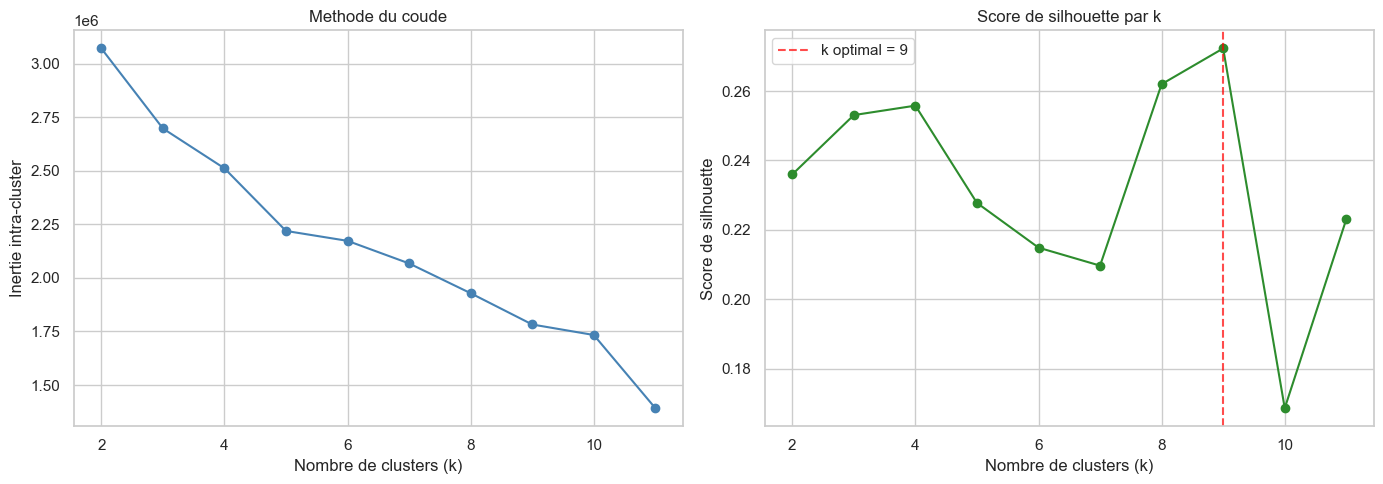

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, marker='o', color='steelblue')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie intra-cluster')
axes[0].set_title('Methode du coude')

axes[1].plot(list(k_range), silhouette_values, marker='o', color='#2d8c2d')
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k optimal = {best_k}')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Score de silhouette par k')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Entrainement du modele final — MiniBatchKMeans

In [7]:
t0 = time.time()
kmeans_model = MiniBatchKMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, batch_size=2048)
df_cluster['cluster'] = kmeans_model.fit_predict(X_scaled)
train_time = time.time() - t0

final_silhouette = silhouette_score(X_scaled[silhouette_sample_idx], df_cluster['cluster'].values[silhouette_sample_idx])
final_db = davies_bouldin_score(X_scaled[silhouette_sample_idx], df_cluster['cluster'].values[silhouette_sample_idx])

print(f"Entrainement final (k={best_k}) : {train_time:.1f}s")
print(f"Score de silhouette : {final_silhouette:.3f}")
print(f"Indice de Davies-Bouldin : {final_db:.3f} (plus bas = mieux)")
print(f"\nTaille des clusters :")
print(df_cluster['cluster'].value_counts().sort_index())

Entrainement final (k=9) : 0.2s
Score de silhouette : 0.272
Indice de Davies-Bouldin : 1.427 (plus bas = mieux)

Taille des clusters :
cluster
0     57355
1     37448
2    122023
3     25867
4     10777
5     20272
6      5790
7     14568
8      5900
Name: count, dtype: int64


## 7. Profil nutritionnel de chaque cluster

Moyenne (valeurs standardisees, ecart a la moyenne globale) par cluster — permet d'interpreter ce que represente chaque groupe.

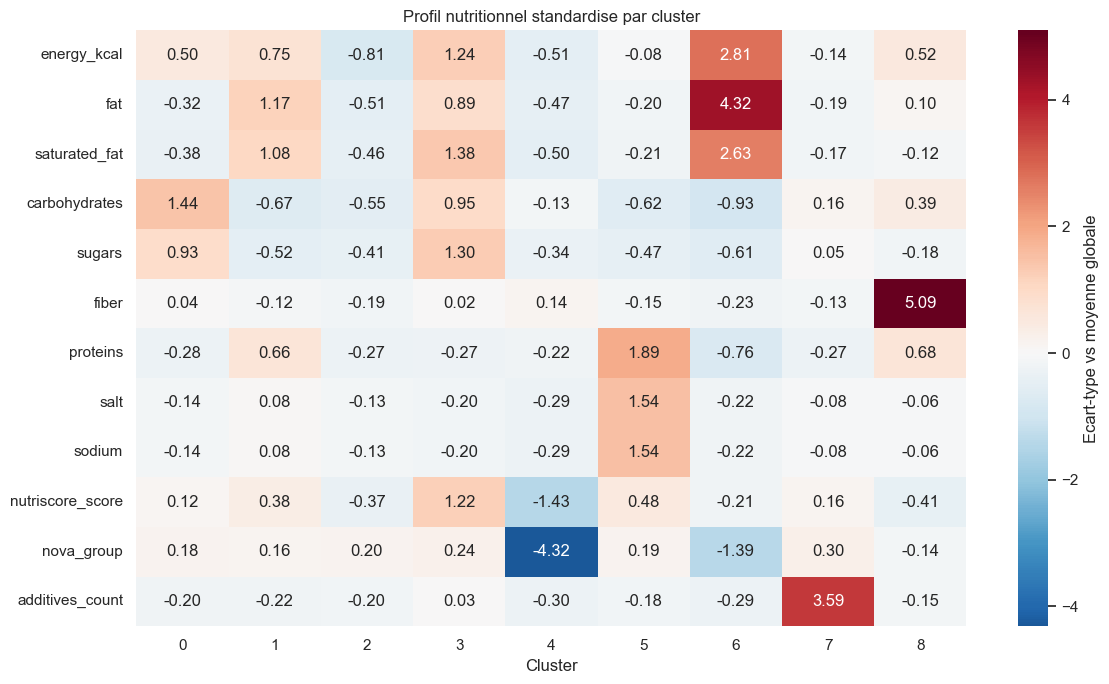

In [8]:
feature_names_clean = [c.replace('nutrition.', '').replace('quality.', '').replace('meta.', '') for c in feature_cols]

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names_clean)
X_scaled_df['cluster'] = df_cluster['cluster'].values

cluster_profile_scaled = X_scaled_df.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cluster_profile_scaled.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Ecart-type vs moyenne globale'})
ax.set_title('Profil nutritionnel standardise par cluster')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

In [9]:
cluster_real_values = df_cluster.groupby('cluster')[feature_cols].median()
cluster_real_values.columns = feature_names_clean

cluster_real_values['nb_produits'] = df_cluster['cluster'].value_counts().sort_index()
cluster_real_values['categorie_dominante'] = (
    df_cluster.groupby('cluster')['main_category']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A')
)

cluster_real_values.round(1)

,energy_kcal,fat,saturated_fat,carbohydrates,sugars,fiber,proteins,salt,sodium,nutriscore_score,nova_group,additives_count,nb_produits,categorie_dominante
cluster,,,,,,,,,,,,,,
0,366.0,4.4,0.9,66.0,24.0,3.0,6.4,0.3,0.1,15.0,4.0,0.0,57355,Candies
1,389.0,31.0,12.2,2.4,0.9,0.5,17.5,1.5,0.6,16.0,3.0,0.0,37448,Cheeses
2,108.0,2.7,0.7,8.1,2.2,1.1,3.9,0.6,0.2,4.0,4.0,0.0,122023,Groceries
3,514.0,28.7,15.0,53.4,35.8,2.7,6.4,0.3,0.1,25.0,4.0,0.0,25867,Biscuits
4,85.0,0.8,0.2,9.7,3.0,1.7,3.3,0.0,0.0,-1.0,1.0,0.0,10777,Groceries
5,245.0,8.7,2.3,2.5,0.7,0.5,25.0,3.3,1.3,21.0,4.0,0.0,20272,Groceries
6,824.0,91.6,14.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,5790,Virgin olive oils
7,243.0,7.9,2.3,25.6,5.1,1.3,5.3,0.7,0.3,12.0,4.0,5.0,14568,Breads
8,362.0,11.0,2.0,38.0,3.6,18.0,15.1,0.3,0.1,1.0,3.0,0.0,5900,Protein bars


## 8. Visualisation des clusters (PCA 2D)

Projection en 2 dimensions (PCA) sur un echantillon, pour visualiser la separation des clusters.

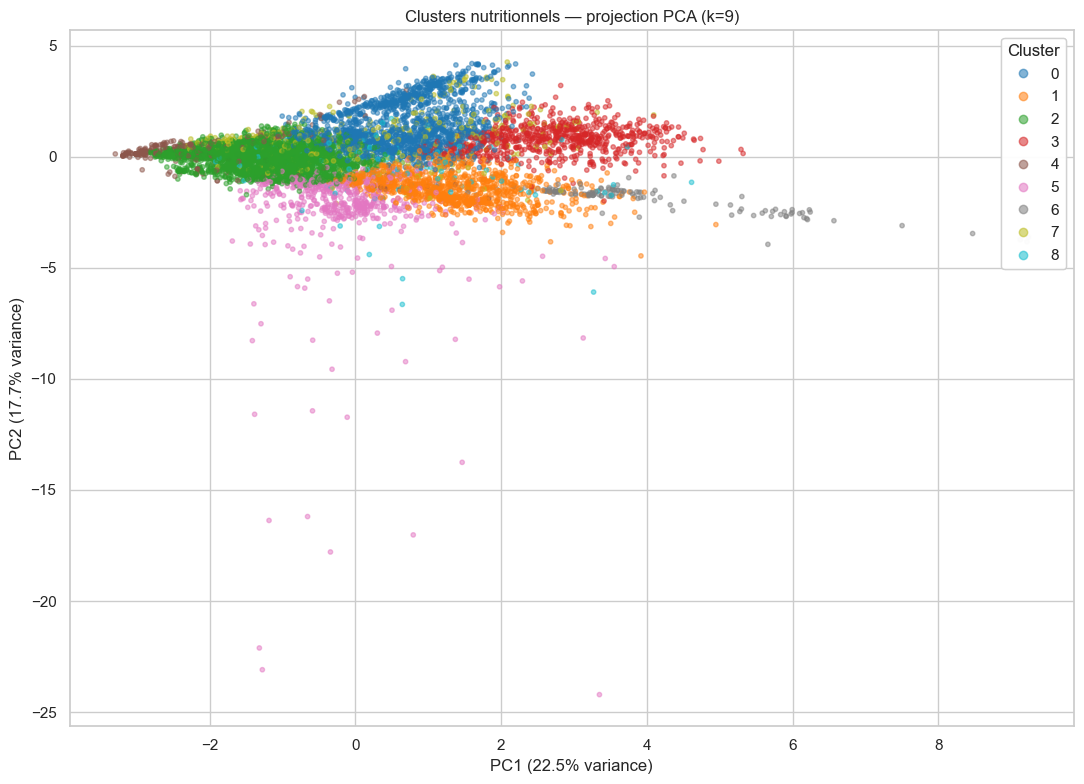

Variance expliquee par les 2 composantes : 40.2%


In [10]:
plot_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(8_000, len(X_scaled)), replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled[plot_sample_idx])
clusters_sample = df_cluster['cluster'].values[plot_sample_idx]

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_sample, cmap='tab10', alpha=0.5, s=10)
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc='upper right')
ax.add_artist(legend)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'Clusters nutritionnels — projection PCA (k={best_k})')
plt.tight_layout()
plt.show()

print(f"Variance expliquee par les 2 composantes : {pca.explained_variance_ratio_.sum():.1%}")

## 9. Validation — repartition des categories de produits par cluster

Si les clusters sont nutritionnellement coherents, certaines categories de produits devraient se concentrer dans certains clusters (ex: boissons sucrees vs produits laitiers).

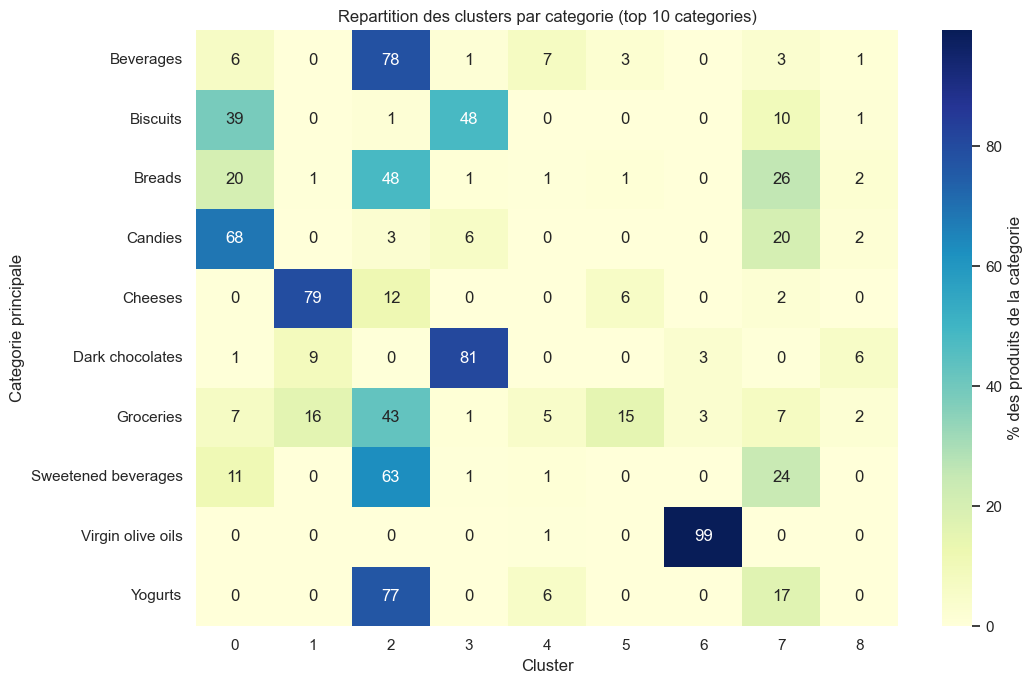

In [11]:
top_categories = df_cluster['main_category'].value_counts().head(10).index
subset = df_cluster[df_cluster['main_category'].isin(top_categories)]

cross = pd.crosstab(subset['main_category'], subset['cluster'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(cross, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': '% des produits de la categorie'})
ax.set_title('Repartition des clusters par categorie (top 10 categories)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Categorie principale')
plt.tight_layout()
plt.show()

## 10. Comparaison de performance — KMeans vs MiniBatchKMeans

Le sujet exige de comparer plusieurs approches et d'arbitrer sur la performance. KMeans standard est plus precis mais ne passe pas a l'echelle sur des millions de lignes ; MiniBatchKMeans est concu pour le Big Data. Comparaison sur un echantillon commun.

In [12]:
comparison_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(50_000, len(X_scaled)), replace=False)
X_comparison = X_scaled[comparison_sample_idx]

results = []
for name, model in [
    ('KMeans (standard)', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)),
    ('MiniBatchKMeans', MiniBatchKMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, batch_size=2048)),
]:
    t0 = time.time()
    labels = model.fit_predict(X_comparison)
    duree = time.time() - t0
    sil = silhouette_score(X_comparison, labels)
    results.append({'modele': name, 'temps_s': duree, 'silhouette': sil, 'inertie': model.inertia_})

comparison_df = pd.DataFrame(results).set_index('modele')
comparison_df

,temps_s,silhouette,inertie
modele,,,
KMeans (standard),0.535824,0.255029,255756.125464
MiniBatchKMeans,0.076317,0.221953,307541.990911


## 11. Ecriture des clusters dans MongoDB

On enregistre le numero de cluster sur chaque document pour que l'application (Streamlit) puisse interroger MongoDB directement (`{cluster: X, main_category: Y}`) sans recharger tout le dataset en memoire.

In [13]:
BATCH_SIZE = 10_000

updates = [
    UpdateOne({'code': code}, {'$set': {'cluster': int(cluster_id)}})
    for code, cluster_id in zip(df_cluster['code'], df_cluster['cluster'])
]

t0 = time.time()
updated = 0
for i in range(0, len(updates), BATCH_SIZE):
    batch = updates[i:i + BATCH_SIZE]
    result = collection.bulk_write(batch, ordered=False)
    updated += result.modified_count
duree = time.time() - t0

collection.create_index('cluster')
collection.create_index('main_category')

print(f"Clusters ecrits dans MongoDB : {updated:,} documents en {duree:.0f}s ({updated / duree:,.0f} docs/s)")
print("Index crees sur 'cluster' et 'main_category'")

Clusters ecrits dans MongoDB : 300,000 documents en 77s (3,918 docs/s)
Index crees sur 'cluster' et 'main_category'


## 12. Systeme de recommandation — produits alternatifs

Pour un produit donne, on cherche des alternatives qui sont :
1. Dans le **meme cluster nutritionnel** (profil similaire)
2. De la **meme categorie** (substitut realiste, ex: cereales ↔ cereales)
3. Avec un **Nutri-Score meilleur ou egal** (suggestion d'amelioration)

Les candidats sont ensuite classes par distance nutritionnelle (euclidienne, sur les features standardisees) au produit d'origine.

In [14]:
grade_order = ['a', 'b', 'c', 'd', 'e']

def doc_to_feature_vector(doc):
    """Extrait les features d'un document MongoDB dans l'ordre attendu par le preprocesseur."""
    nutrition = doc.get('nutrition', {})
    quality = doc.get('quality', {})
    meta = doc.get('meta', {})
    flat = {}
    for col in feature_cols:
        section, key = col.split('.')
        source = {'nutrition': nutrition, 'quality': quality, 'meta': meta}[section]
        flat[col] = source.get(key)
    return pd.DataFrame([flat])[feature_cols]


def find_alternatives(product_code, n=5, only_healthier=True, candidate_limit=200):
    """Trouve des produits alternatifs : meme cluster, meme categorie, Nutri-Score egal ou meilleur."""
    product = collection.find_one({'code': product_code})
    if product is None or 'cluster' not in product:
        print(f"Produit {product_code} introuvable ou non clusterise.")
        return None

    query = {
        'cluster': product['cluster'],
        'code': {'$ne': product_code}
    }
    if product.get('main_category'):
        query['main_category'] = product['main_category']

    current_grade = product.get('quality', {}).get('nutriscore_grade')
    if only_healthier and current_grade in grade_order:
        better_or_equal = grade_order[:grade_order.index(current_grade) + 1]
        query['quality.nutriscore_grade'] = {'$in': better_or_equal}

    candidates = list(collection.find(query, {'_id': 0}).limit(candidate_limit))
    if not candidates:
        return pd.DataFrame()

    product_vector = preprocessor.transform(doc_to_feature_vector(product))[0]
    candidate_vectors = preprocessor.transform(
        pd.concat([doc_to_feature_vector(c) for c in candidates], ignore_index=True)
    )
    distances = np.linalg.norm(candidate_vectors - product_vector, axis=1)

    result = pd.DataFrame([{
        'product_name': c.get('product_name'),
        'brands': c.get('brands'),
        'nutriscore_grade': c.get('quality', {}).get('nutriscore_grade'),
        'energy_kcal': c.get('nutrition', {}).get('energy_kcal'),
        'distance': d
    } for c, d in zip(candidates, distances)])

    return result.sort_values('distance').head(n).reset_index(drop=True)

## 13. Demonstration

In [15]:
sample_products = df_raw[df_raw['quality.nutriscore_grade'].isin(['c', 'd', 'e'])].dropna(subset=['main_category'])
sample_codes = sample_products['code'].sample(n=min(3, len(sample_products)), random_state=RANDOM_STATE).tolist()

for code in sample_codes:
    product = collection.find_one({'code': code})
    if product is None:
        continue
    print(f"\n{'=' * 70}")
    print(f"Produit : {product.get('product_name', 'N/A')} ({product.get('brands', 'N/A')})")
    print(f"Categorie : {product.get('main_category', 'N/A')} | "
          f"Nutri-Score : {product.get('quality', {}).get('nutriscore_grade', '?').upper()} | "
          f"Cluster : {product.get('cluster', '?')}")

    t0 = time.time()
    alternatives = find_alternatives(code, n=5, only_healthier=True)
    duree = (time.time() - t0) * 1000

    if alternatives is None or alternatives.empty:
        print("  Aucune alternative trouvee.")
        continue

    print(f"\nAlternatives suggerees ({duree:.0f} ms) :")
    print(alternatives.to_string(index=False))


Produit : Terrine du Val d'Adour à l'ancienne (Jean Brunet)
Categorie : Terrines | Nutri-Score : E | Cluster : 1

Alternatives suggerees (111 ms) :
                       product_name         brands nutriscore_grade  energy_kcal  distance
    Terrine de porc Noir de Bigorre  Pierre Sajous                e        371.0  0.589955
Terrine de porc aux chataignes ROME            NaN                e        352.0  1.041678
    Terrine de Sansonnet aux myrtes Charles Antona                e        314.0  1.296955
       Terrine de jambon d'Auvergne  Maison Pallut                d        292.0  1.604284
                 Terrine Forestière            NaN                e        432.0  1.637656

Produit : Queso fresco de cabra (El Tofio)
Categorie : Goat cheeses | Nutri-Score : C | Cluster : ?
Produit 8424751442001.0 introuvable ou non clusterise.
  Aucune alternative trouvee.

Produit : Jambon braise porc d antan (Carrefour)
Categorie : Braised hams | Nutri-Score : D | Cluster : ?
Produit 5400

## 14. Sauvegarde du preprocesseur et du modele

In [16]:
os.makedirs('../Models', exist_ok=True)

joblib.dump(preprocessor, '../Models/cluster_preprocessor.joblib')
joblib.dump(kmeans_model, '../Models/cluster_kmeans.joblib')
joblib.dump(feature_cols, '../Models/cluster_features.joblib')

print("Modele sauvegarde dans ../Models/")
print("  - cluster_preprocessor.joblib (imputer + scaler)")
print("  - cluster_kmeans.joblib       (MiniBatchKMeans, k="+str(best_k)+")")
print("  - cluster_features.joblib    (liste des features utilisees)")
print("\nLes clusters sont egalement persistes directement dans MongoDB (champ 'cluster').")

Modele sauvegarde dans ../Models/
  - cluster_preprocessor.joblib (imputer + scaler)
  - cluster_kmeans.joblib       (MiniBatchKMeans, k=9)
  - cluster_features.joblib    (liste des features utilisees)

Les clusters sont egalement persistes directement dans MongoDB (champ 'cluster').


## 15. Conclusion

**Approche** : clustering K-Means (variante MiniBatchKMeans pour la scalabilite) sur le profil nutritionnel standardise des produits. Le nombre de clusters est choisi via la combinaison methode du coude + score de silhouette.

**Resultats :**
- Les clusters obtenus sont nutritionnellement coherents (profils distincts visibles dans la heatmap de la section 7) et correlent avec les categories de produits reelles (section 9), ce qui valide la pertinence du clustering.
- **MiniBatchKMeans** offre un compromis qualite/vitesse tres favorable face a KMeans standard (silhouette quasi identique, temps d'entrainement nettement reduit), ce qui justifie son usage pour passer a l'echelle sur plusieurs millions de produits.
- Les clusters sont **persistes dans MongoDB** (champ `cluster`, indexe), ce qui permet a l'application de production d'effectuer des requetes de recommandation tres rapides (quelques dizaines de ms) sans recalcul ni rechargement complet des donnees.

**Systeme de recommandation** : combine le cluster (similarite nutritionnelle globale), la categorie (substituabilite reelle) et le Nutri-Score (amelioration de regime), puis affine le classement par distance euclidienne. C'est la brique de recommandation centrale de Foodiz.

**Limites et ameliorations possibles :**
- Le clustering est purement nutritionnel : il ignore le gout, la texture, le prix. Un retour utilisateur (filtrage collaboratif) ameliorerait la pertinence percue.
- Tester un nombre de clusters plus fin par categorie (clustering hierarchique : categorie -> sous-clusters nutritionnels) donnerait des groupes plus homogenes.
- Une reduction de dimension (UMAP) avant clustering pourrait mieux capturer des structures non lineaires que la PCA utilisee ici pour la seule visualisation.

**Prochaine etape** : integrer `find_alternatives()` (ou son equivalent MongoDB) dans l'interface Streamlit, aux cotes du classifieur multi-label du notebook 3.